 # E-commerce Sales Analysis with Customer Insights


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import zipfile

zip_path = r"Downloads\archive (22).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()



In [3]:
# load dataset
df = pd.read_csv("data.csv", encoding="latin1")
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# Basic Data Understanding

In [4]:
df.shape

(541909, 8)

In [5]:
# Missing value
df.isnull().sum()


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(5268)

In [7]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


# Data Cleaning

In [9]:
# Remove Missing Customer ID
df = df.dropna(subset=["CustomerID"])

In [10]:
# Remove negative Quantity (Returns)
df = df[df["Quantity"] >0]

In [11]:
# Remove zero or negative price
df = df[df["UnitPrice"]>0]

In [12]:
# Remove Duplicates
df = df.drop_duplicates()

In [13]:
# Convert date column
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Feature Engineering

In [14]:
# Create Revenue
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [15]:
# create year and month column
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

In [16]:
df.shape

(392692, 12)

In [17]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Year', 'Month',
       'YearMonth'],
      dtype='object')

# KPI


In [18]:
# Total Revenue
print("Total Revenue:", df['Revenue'].sum())
# Total Orders
print("Total Orders:", df['InvoiceNo'].nunique())
# Total Customers
print("Total Customers:", df['CustomerID'].nunique())
# Average Order Value
print("Average Order Value:",
      df['Revenue'].sum() / df['InvoiceNo'].nunique())

Total Revenue: 8887208.894000001
Total Orders: 18532
Total Customers: 4338
Average Order Value: 479.56016047917126


# EDA

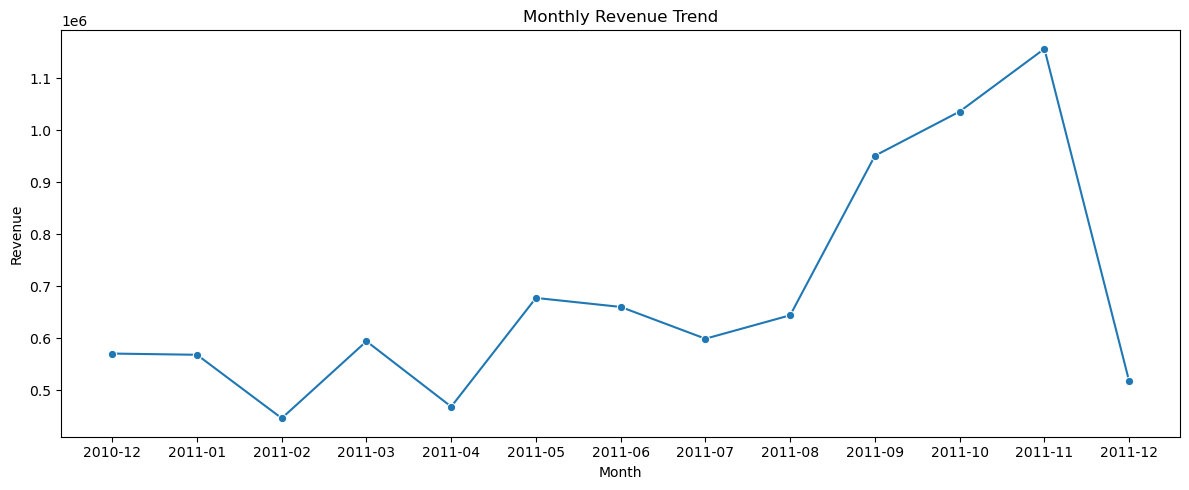

In [19]:
# 1. Monthly Revenue Trend

monthly_sales = (
    df.groupby('YearMonth')['Revenue']
    .sum()
    .reset_index()
)


monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

plt.figure(figsize=(12,5))
sns.lineplot(x='YearMonth', y='Revenue', data=monthly_sales, marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


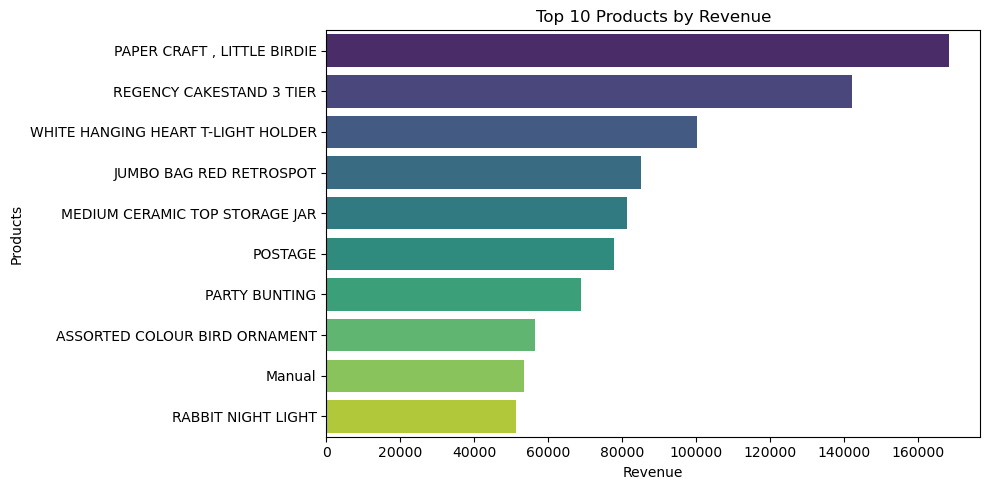

In [20]:
# 2.Top 10 Products by Revenue
top_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,5))
sns.barplot(
    x='Revenue',
    y='Description',
    data=top_products,
    hue='Description',   # 👈 warning fix
    palette='viridis',
    legend=False
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Products")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

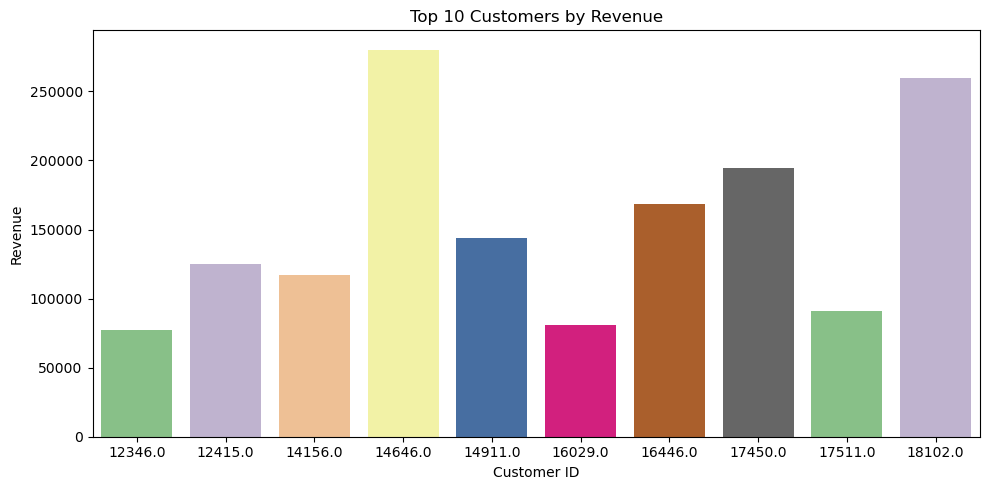

In [21]:
# 3. Top 10 Customers


top_customers = (
    df.groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,5))
sns.barplot(
    x='CustomerID',
    y='Revenue',
    data=top_customers,
    hue='CustomerID',  
    palette='Accent',
    legend=False
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


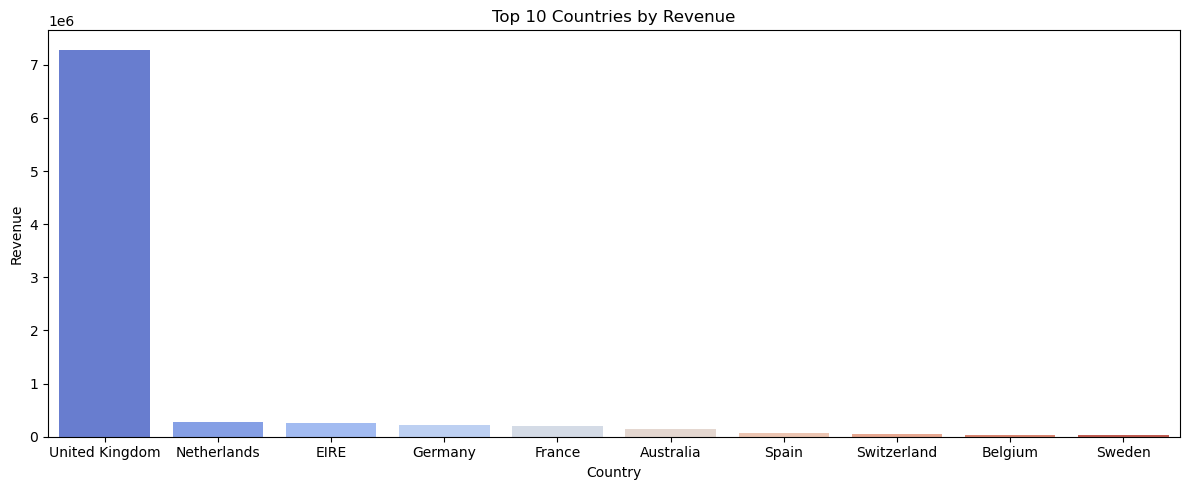

In [22]:
# 4. Top 10 Countries by Revenue
country_sales = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12,5))
sns.barplot(
    x='Country',
    y='Revenue',
    data=country_sales,
    hue='Country',   # 👈 warning fix
    palette='coolwarm',
    legend=False
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [23]:
# 5.Customer Retention Rate


# Count number of orders per customer
customer_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()

# Identify repeat customers (more than 1 order)
repeat_customers = customer_orders[customer_orders > 1]

# Calculate retention rate
retention_rate = len(repeat_customers) / len(customer_orders) * 100

print("\nCustomer Retention Rate: {:.2f}%".format(retention_rate))



Customer Retention Rate: 65.58%


# Insight And Recommendation

Key Insights:

1. Monthly revenue trend shows fluctuations indicating seasonal demand patterns.
2. A small number of products contribute significantly to total revenue, indicating product concentration.
3. Certain countries generate higher revenue, highlighting strong geographic markets.
4. Top customers contribute a major portion of total sales, showing customer dependency.
5. Repeat customer analysis indicates that a portion of customers return for multiple purchases, which is a positive sign for business growth.

Recommendations:

1. Focus on high-performing products to maximize revenue.
2. Improve marketing strategies in top-performing countries.
3. Provide loyalty programs to retain repeat customers.
4. Identify reasons behind one-time customers and improve retention strategies.
5. Analyze seasonal trends to optimize inventory and sales planning.



In [24]:
pip install pymysql sqlalchemy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [25]:
import sys

sys.path.append(r'c:\users\hp\appdata\roaming\python\python313\site-packages')

import pymysql
from sqlalchemy import create_engine


user = 'root'
password = 'Pass123'
host = 'localhost'
database = 'analysis'

engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}:3306/{database}")

df.to_sql(name='sale', con=engine, if_exists='replace', index=False)



392692